# **Dataset:** ICBHI 2017 Respiratory Sound Database
### **Source:** https://bhichallenge.med.auth.gr/ICBHI_2017_Challenge
### **Total Files:** 920 recordings
### **Patients:** 126

## 1. Setup and Imports

In [29]:
import os
import sys
import librosa
import librosa.display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

# Add project root to path
sys.path.append('..')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Create figures directory
figures_dir = Path("../reports/figures/icbhi")
figures_dir.mkdir(parents=True, exist_ok=True)

## 2. Define Path

In [30]:
# Path to ICBHI dataset
ICBHI_PATH = Path("../sound_data/icbhi")

print(f"ICBHI folder exists: {ICBHI_PATH.exists()}")
print(f"Contents: {len(list(ICBHI_PATH.glob('*')))} files total")

ICBHI folder exists: True
Contents: 1846 files total


## 3. Separate Audio and Annotation Files

In [31]:
# Get all .wav files (audio)
audio_files = list(ICBHI_PATH.glob("*.wav"))
print(f"Audio files (.wav): {len(audio_files)}")

# Get all .txt files (annotations)
annotation_files = list(ICBHI_PATH.glob("*.txt"))
print(f"Annotation files (.txt): {len(annotation_files)}")

# Show first 5 of each
print("\nSample audio files:")
for f in audio_files[:5]:
    print(f"  - {f.name}")

print("\nSample annotation files:")
for f in annotation_files[:5]:
    print(f"  - {f.name}")
    
# Match Checking
audio_names = {f.stem for f in audio_files}
annotation_names = {f.stem for f in annotation_files}
common_names = audio_names.intersection(annotation_names)
    
print(f"\n Paired files (wav + txt): {len(common_names)} ({len(common_names)/len(audio_files)*100:.1f}%)")

Audio files (.wav): 920
Annotation files (.txt): 922

Sample audio files:
  - 101_1b1_Al_sc_Meditron.wav
  - 101_1b1_Pr_sc_Meditron.wav
  - 102_1b1_Ar_sc_Meditron.wav
  - 103_2b2_Ar_mc_LittC2SE.wav
  - 104_1b1_Al_sc_Litt3200.wav

Sample annotation files:
  - 101_1b1_Al_sc_Meditron.txt
  - 101_1b1_Pr_sc_Meditron.txt
  - 102_1b1_Ar_sc_Meditron.txt
  - 103_2b2_Ar_mc_LittC2SE.txt
  - 104_1b1_Al_sc_Litt3200.txt

 Paired files (wav + txt): 920 (100.0%)


## 4. Parse Filename Information

### Filename format: `[patient]_[recording]_[location]_[mode]_[equipment].wav`

### **Example:** `101_1b1_Al_sc_Meditron.wav`
#### - 101 = patient ID
#### - 1b1 = recording index
#### - Al = anterior left chest location
#### - sc = single channel
#### - Meditron = recording equipment

In [32]:
def parse_icbhi_filename(filename):
    """Parse ICBHI filename to extract metadata"""
    parts = filename.stem.split('_')
    if len(parts) >= 4:
        return {
            'filename': filename.name,
            'patient_id': parts[0],
            'recording_index': parts[1],
            'chest_location': parts[2],
            'recording_mode': parts[3] if len(parts) > 3 else 'unknown',
            'equipment': parts[4] if len(parts) > 4 else 'unknown',
            'has_annotation': filename.stem in annotation_names
        }
    return None

file_info = []
for f in audio_files:
    info = parse_icbhi_filename(f)
    if info:
        file_info.append(info)

df_files = pd.DataFrame(file_info)
print(f"Parsed {len(df_files)} files")
df_files.head()

Parsed 920 files


,filename,patient_id,recording_index,chest_location,recording_mode,equipment,has_annotation
0,101_1b1_Al_sc_Meditron.wav,101,1b1,Al,sc,Meditron,True
1,101_1b1_Pr_sc_Meditron.wav,101,1b1,Pr,sc,Meditron,True
2,102_1b1_Ar_sc_Meditron.wav,102,1b1,Ar,sc,Meditron,True
3,103_2b2_Ar_mc_LittC2SE.wav,103,2b2,Ar,mc,LittC2SE,True
4,104_1b1_Al_sc_Litt3200.wav,104,1b1,Al,sc,Litt3200,True


## 5. Basic Dataset Statistics

### **Chest location** (Trachea (Tc), {Anterior (A), Posterior (P), Lateral (L)} {left (l), right (r)})
#### Ar- Anterior right
#### Al - Anterior left
#### Pl- Posterior left
#### Pr - Posterior right
#### Tc- Trachea
#### Lr - Lateral right
#### Ll - Lateral left


In [33]:
print("="*60)
print("Basic Dataset Statistics")
print("="*60)

print(f"Total patients: {df_files['patient_id'].nunique()}")
print(f"Total recordings: {len(df_files)}")
print(f"Chest locations: {df_files['chest_location'].unique().tolist()}")
print(f"Recording modes: {df_files['recording_mode'].unique().tolist()}")
print(f"Equipment types: {df_files['equipment'].unique().tolist()}")

Basic Dataset Statistics
Total patients: 126
Total recordings: 920
Chest locations: ['Al', 'Pr', 'Ar', 'Ll', 'Lr', 'Pl', 'Tc']
Recording modes: ['sc', 'mc']
Equipment types: ['Meditron', 'LittC2SE', 'Litt3200', 'AKGC417L']


## 6. Visualizations_1

### Visualization 1: Patient Distribution (Recordings per Patient)


Visualization 1: Recordings per Patient Distribution


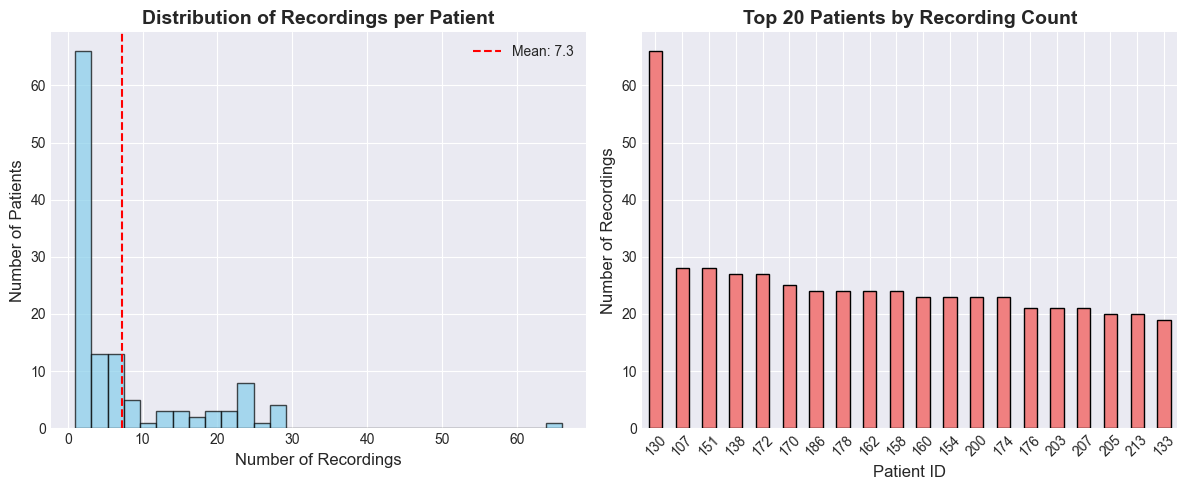

In [34]:
print("\n" + "="*60)
print("Visualization 1: Recordings per Patient Distribution")
print("="*60)

patient_counts = df_files['patient_id'].value_counts()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(patient_counts, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Recordings per Patient', fontsize=14, fontweight='bold')
plt.xlabel('Number of Recordings', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.axvline(patient_counts.mean(), color='red', linestyle='--', 
            label=f'Mean: {patient_counts.mean():.1f}')
plt.legend()

plt.subplot(1, 2, 2)
patient_counts.head(20).plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title('Top 20 Patients by Recording Count', fontsize=14, fontweight='bold')
plt.xlabel('Patient ID', fontsize=12)
plt.ylabel('Number of Recordings', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(figures_dir / 'icbhi01_patient_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

 ### Visualization 2: Chest Location Distribution



Visualization 2: Chest Location Distribution
chest_location
Ar    168
Al    162
Pl    139
Pr    132
Tc    130
Lr    112
Ll     77
Name: count, dtype: int64


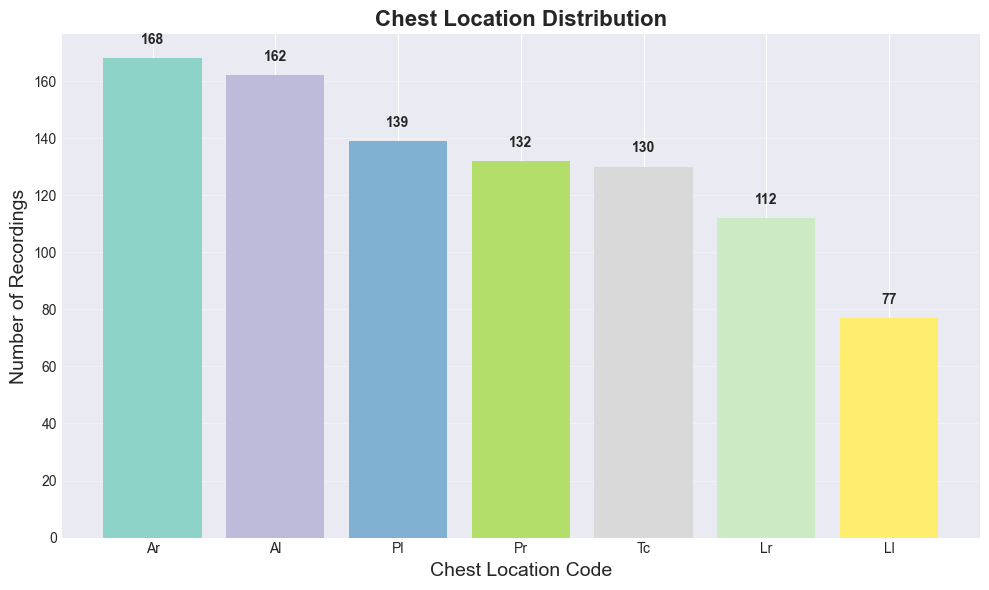

In [35]:
print("\n" + "="*60)
print("Visualization 2: Chest Location Distribution")
print("="*60)

location_counts = df_files['chest_location'].value_counts()
print(location_counts)

plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(location_counts)), location_counts.values, 
               color=plt.cm.Set3(np.linspace(0, 1, len(location_counts))))
plt.title('Chest Location Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Chest Location Code', fontsize=14)
plt.ylabel('Number of Recordings', fontsize=14)
plt.xticks(range(len(location_counts)), location_counts.index)
plt.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, location_counts.values)):
    plt.text(i, val + 5, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(figures_dir / 'icbhi02_location_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualization 3: Recording Mode Distribution


Visualization 3: Recording Mode Distribution
recording_mode
mc    732
sc    188
Name: count, dtype: int64


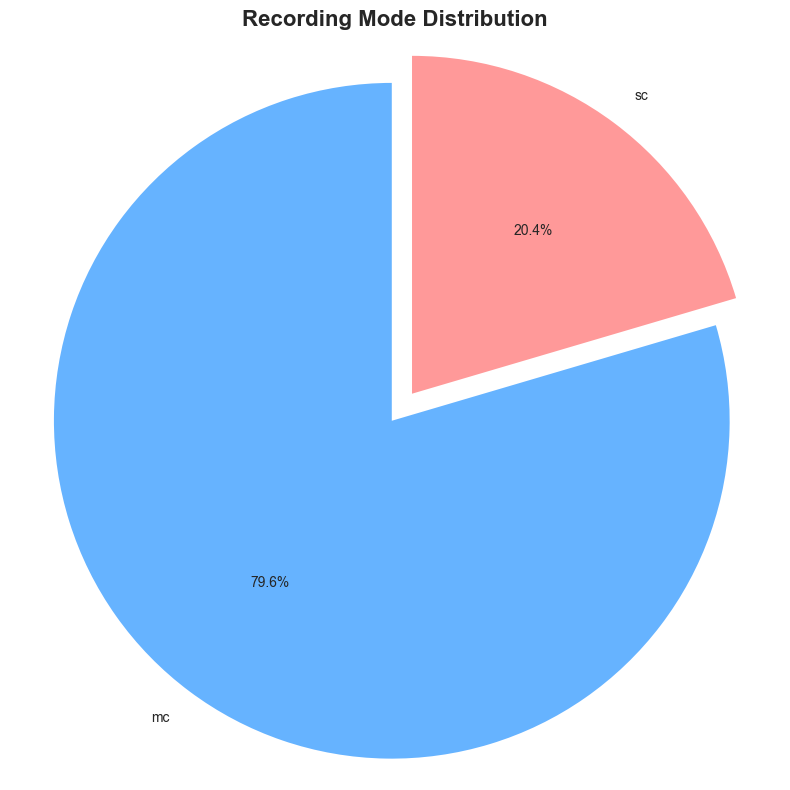

In [36]:
print("\n" + "="*60)
print("Visualization 3: Recording Mode Distribution")
print("="*60)

mode_counts = df_files['recording_mode'].value_counts()
print(mode_counts)

plt.figure(figsize=(8, 8))
plt.pie(mode_counts.values, labels=mode_counts.index, autopct='%1.1f%%',
        colors=['#66b3ff', '#ff9999'], startangle=90, explode=[0.05, 0.05])
plt.title('Recording Mode Distribution', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.savefig(figures_dir / 'icbhi03_mode_pie.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualization 4: Equipment Distribution


Visualization 4: Recording Equipment Distribution
equipment
AKGC417L    646
Meditron    127
LittC2SE     87
Litt3200     60
Name: count, dtype: int64


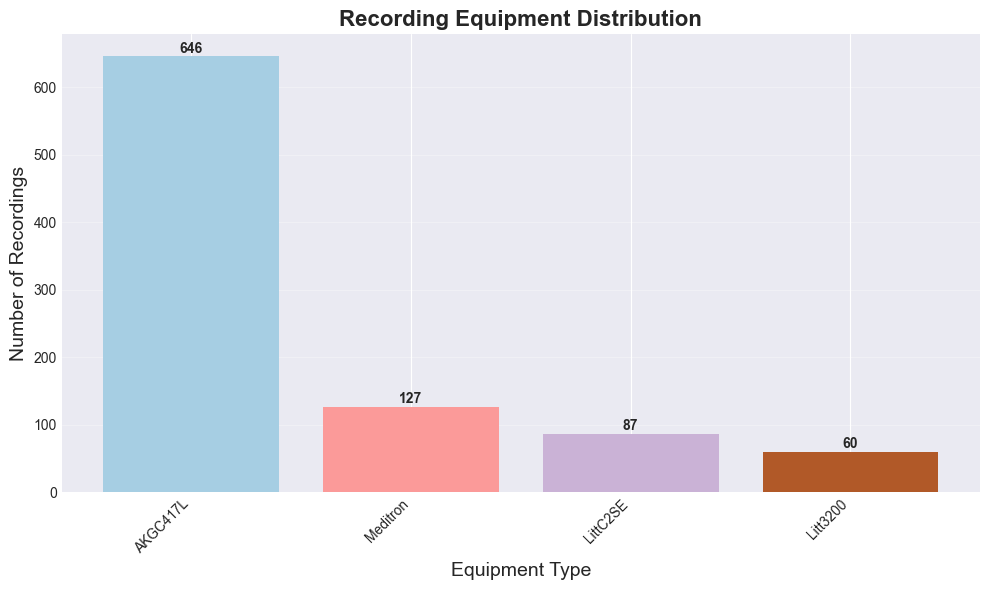

In [37]:
print("\n" + "="*60)
print("Visualization 4: Recording Equipment Distribution")
print("="*60)

equipment_counts = df_files['equipment'].value_counts()
print(equipment_counts)

plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(equipment_counts)), equipment_counts.values, 
               color=plt.cm.Paired(np.linspace(0, 1, len(equipment_counts))))
plt.title('Recording Equipment Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Equipment Type', fontsize=14)
plt.ylabel('Number of Recordings', fontsize=14)
plt.xticks(range(len(equipment_counts)), equipment_counts.index, rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

for i, (bar, val) in enumerate(zip(bars, equipment_counts.values)):
    plt.text(i, val + 5, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(figures_dir / 'icbhi04_equipment_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Audio Analysis Functions

In [38]:
def extract_audio_features(file_path):
    """Extract comprehensive audio features"""
    try:
        y, sr = librosa.load(file_path, sr=None)
        duration = len(y) / sr
        
        features = {
            'file': file_path.name,
            'duration': duration,
            'sample_rate': sr,
            'samples': len(y),
            'rms_mean': np.mean(librosa.feature.rms(y=y)),
            'rms_std': np.std(librosa.feature.rms(y=y)),
            'zcr_mean': np.mean(librosa.feature.zero_crossing_rate(y)),
            'zcr_std': np.std(librosa.feature.zero_crossing_rate(y)),
            'spectral_centroid': np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)),
            'spectral_bandwidth': np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr)),
            'spectral_rolloff': np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
        }
        
        # Extract MFCCs
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        for i in range(13):
            features[f'mfcc_{i+1}'] = np.mean(mfccs[i])
            
        return features, y, sr
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None, None, None

## 8. Extract Features from Sample

In [39]:
sample_size = min(100, len(audio_files))
sample_files = audio_files[:sample_size]

print(f"\nExtracting features from {sample_size} files...")
audio_features = []
for f in sample_files:
    features, _, _ = extract_audio_features(f)
    if features:
        audio_features.append(features)

df_audio = pd.DataFrame(audio_features)
print(f"Extracted features from {len(df_audio)} files")
df_audio.head()


Extracting features from 100 files...
Extracted features from 100 files


,file,duration,sample_rate,samples,rms_mean,rms_std,zcr_mean,zcr_std,spectral_centroid,spectral_bandwidth,...,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13
0,101_1b1_Al_sc_Meditron.wav,20.000,44100,882000,0.053982,0.026954,0.001192,0.001074,291.511393,1685.710873,...,44.194176,31.550392,25.432344,22.346970,19.192673,15.791864,13.740938,13.566976,13.650920,11.990160
1,101_1b1_Pr_sc_Meditron.wav,20.000,44100,882000,0.033046,0.015870,0.001184,0.001359,398.452034,2086.792130,...,34.708996,23.990013,24.633614,28.252838,27.673643,22.431122,16.845181,14.204302,13.637769,12.224164
2,102_1b1_Ar_sc_Meditron.wav,20.000,44100,882000,0.021396,0.010526,0.001393,0.001684,479.680354,2259.105117,...,32.625652,20.025837,23.742645,31.376186,31.486959,22.154291,9.889423,2.208259,1.571832,5.137074
3,103_2b2_Ar_mc_LittC2SE.wav,20.000,44100,882000,0.245882,0.134919,0.000636,0.000846,303.540148,1731.751037,...,34.043316,27.111345,24.918638,23.724136,21.149410,17.839611,15.530238,14.591239,13.898755,12.502522
4,104_1b1_Al_sc_Litt3200.wav,15.856,4000,63424,0.075943,0.041452,0.036546,0.017768,160.261320,189.978318,...,-5.406459,17.699913,30.789391,27.280178,13.034311,0.667006,-1.238710,5.876164,7.959642,8.025264


## 9. Visualizations_2

 ### Visualization 5: Duration Distribution


Visualization 5: Recording Duration Distribution
Duration stats:
  Mean: 24.52s
  Median: 20.00s
  Min: 12.46s
  Max: 86.20s
  Std: 14.43s


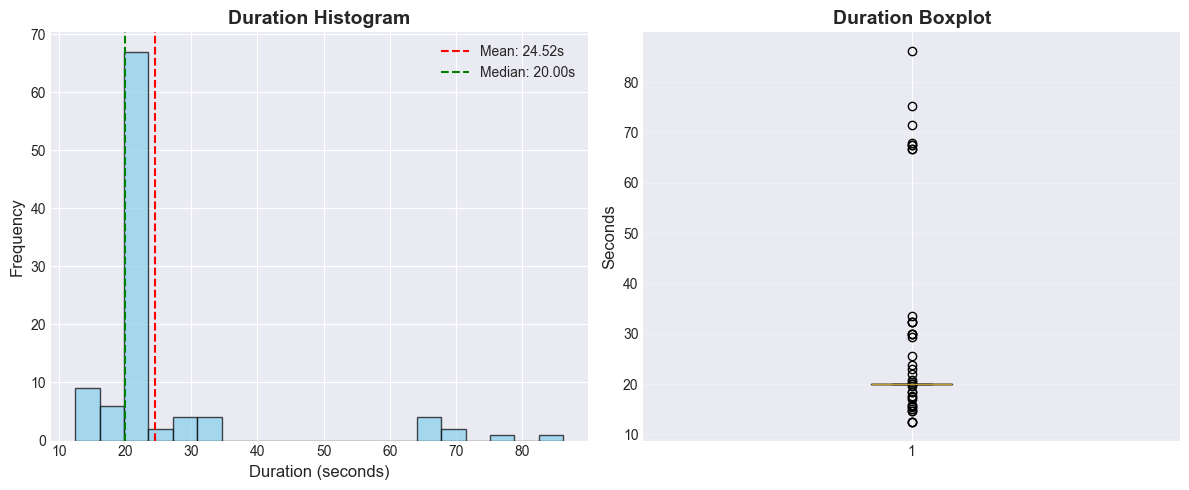

In [40]:
print("\n" + "="*60)
print("Visualization 5: Recording Duration Distribution")
print("="*60)

print(f"Duration stats:")
print(f"  Mean: {df_audio['duration'].mean():.2f}s")
print(f"  Median: {df_audio['duration'].median():.2f}s")
print(f"  Min: {df_audio['duration'].min():.2f}s")
print(f"  Max: {df_audio['duration'].max():.2f}s")
print(f"  Std: {df_audio['duration'].std():.2f}s")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_audio['duration'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Duration Histogram', fontsize=14, fontweight='bold')
plt.xlabel('Duration (seconds)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(df_audio['duration'].mean(), color='red', linestyle='--', 
            label=f"Mean: {df_audio['duration'].mean():.2f}s")
plt.axvline(df_audio['duration'].median(), color='green', linestyle='--', 
            label=f"Median: {df_audio['duration'].median():.2f}s")
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot(df_audio['duration'])
plt.title('Duration Boxplot', fontsize=14, fontweight='bold')
plt.ylabel('Seconds', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(figures_dir / 'icbhi05_duration_dist.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualization 6: Sample Rate Analysis


Visualization 6: Sample Rate Analysis
sample_rate
44100    61
4000     39
Name: count, dtype: int64


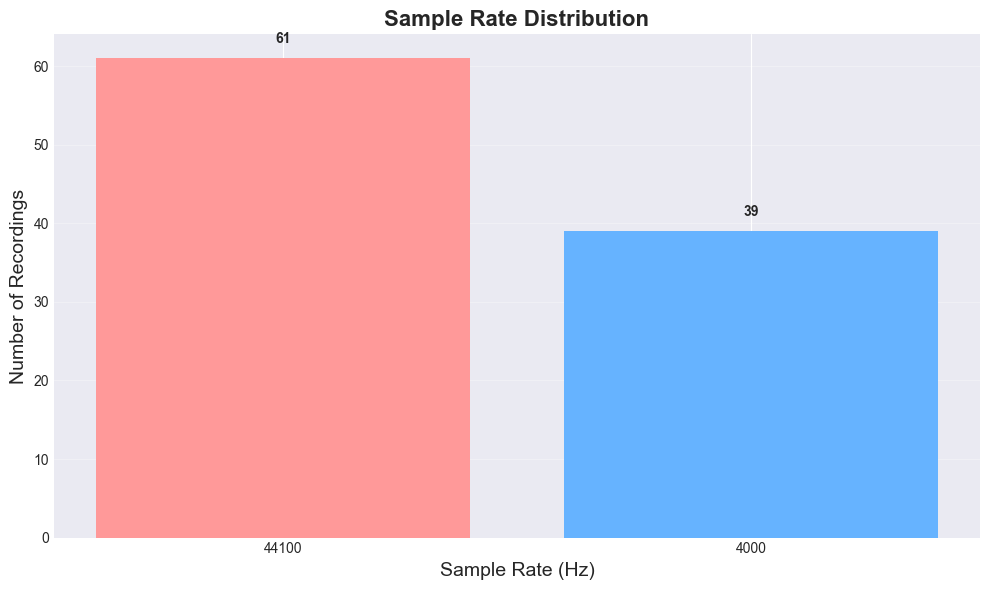

In [41]:
print("\n" + "="*60)
print("Visualization 6: Sample Rate Analysis")
print("="*60)

sample_rate_counts = df_audio['sample_rate'].value_counts()
print(sample_rate_counts)

plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(sample_rate_counts)), sample_rate_counts.values, 
               color=['#ff9999', '#66b3ff', '#99ff99'])
plt.title('Sample Rate Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Sample Rate (Hz)', fontsize=14)
plt.ylabel('Number of Recordings', fontsize=14)
plt.xticks(range(len(sample_rate_counts)), sample_rate_counts.index)
plt.grid(True, alpha=0.3, axis='y')

for i, (bar, val) in enumerate(zip(bars, sample_rate_counts.values)):
    plt.text(i, val + 2, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(figures_dir / 'icbhi06_sample_rates.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualization 7: RMS Energy Distribution


Visualization 7: RMS Energy Distribution


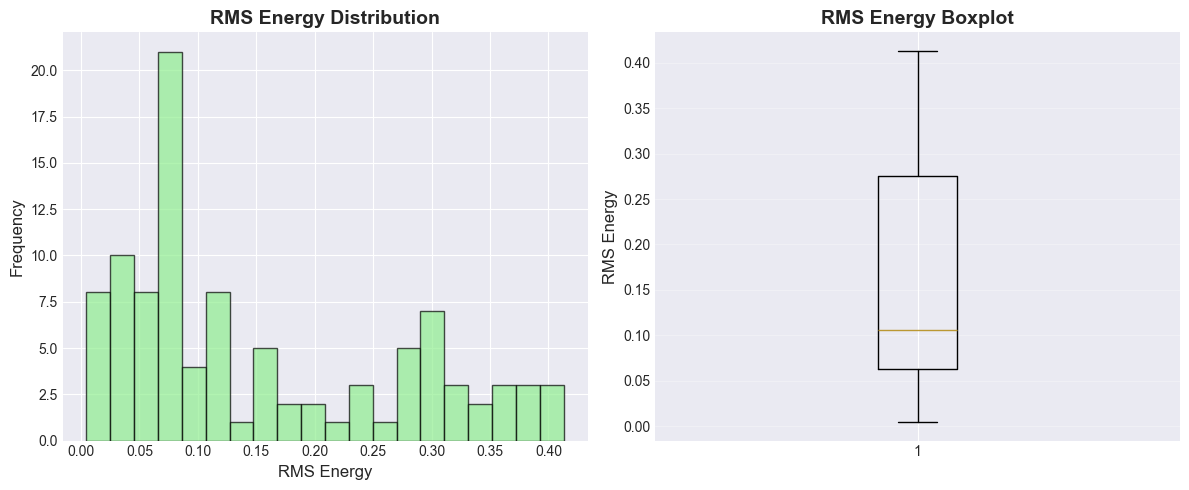

In [42]:
print("\n" + "="*60)
print("Visualization 7: RMS Energy Distribution")
print("="*60)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_audio['rms_mean'], bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
plt.title('RMS Energy Distribution', fontsize=14, fontweight='bold')
plt.xlabel('RMS Energy', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.subplot(1, 2, 2)
plt.boxplot(df_audio['rms_mean'])
plt.title('RMS Energy Boxplot', fontsize=14, fontweight='bold')
plt.ylabel('RMS Energy', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(figures_dir / 'icbhi07_rms_dist.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualization 8: Zero-Crossing Rate Distribution


Visualization 8: Zero-Crossing Rate Distribution


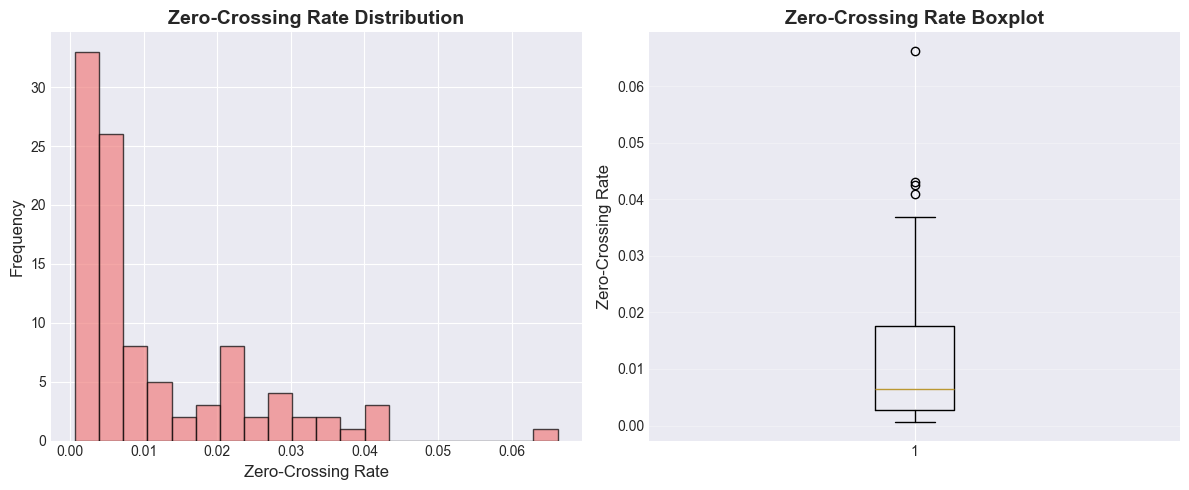

In [43]:
print("\n" + "="*60)
print("Visualization 8: Zero-Crossing Rate Distribution")
print("="*60)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_audio['zcr_mean'], bins=20, color='lightcoral', edgecolor='black', alpha=0.7)
plt.title('Zero-Crossing Rate Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Zero-Crossing Rate', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.subplot(1, 2, 2)
plt.boxplot(df_audio['zcr_mean'])
plt.title('Zero-Crossing Rate Boxplot', fontsize=14, fontweight='bold')
plt.ylabel('Zero-Crossing Rate', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(figures_dir / 'icbhi08_zcr_dist.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualization 9: Spectral Centroid Distribution

 ## 8. Audio Analysis - Spectrogram Visualization


Visualization 9: Spectral Centroid Distribution


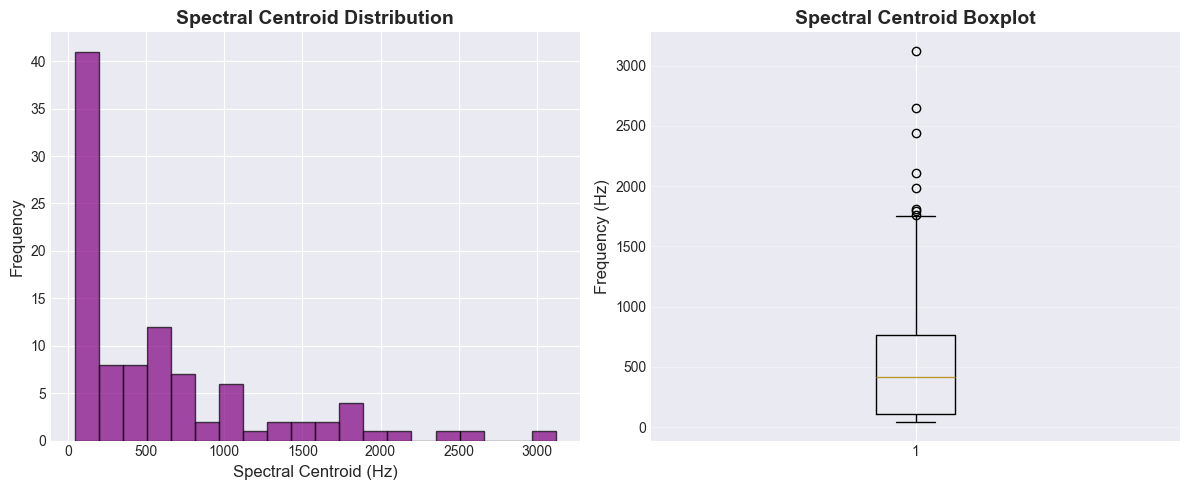

In [44]:
print("\n" + "="*60)
print("Visualization 9: Spectral Centroid Distribution")
print("="*60)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_audio['spectral_centroid'], bins=20, color='purple', edgecolor='black', alpha=0.7)
plt.title('Spectral Centroid Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Spectral Centroid (Hz)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.subplot(1, 2, 2)
plt.boxplot(df_audio['spectral_centroid'])
plt.title('Spectral Centroid Boxplot', fontsize=14, fontweight='bold')
plt.ylabel('Frequency (Hz)', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(figures_dir / 'icbhi09_spectral_centroid.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualization 10: MFCC Heatmap (Average Across All Files)


Visualization 10: Average MFCC Heatmap


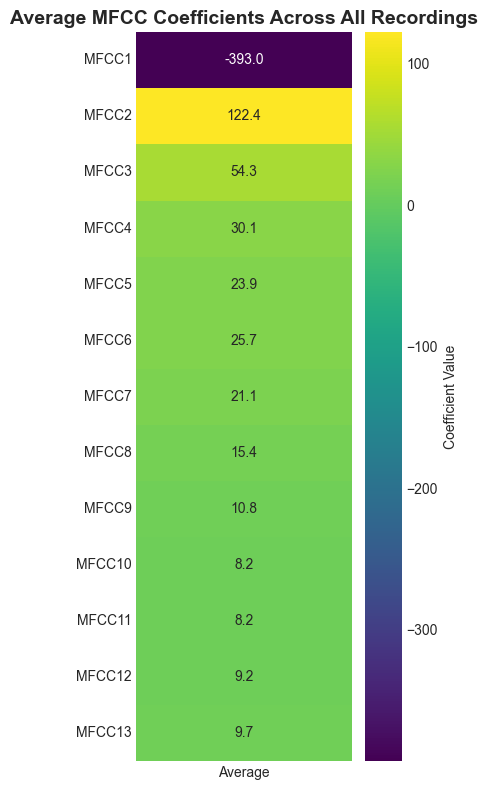

In [45]:
print("\n" + "="*60)
print("Visualization 10: Average MFCC Heatmap")
print("="*60)

mfcc_cols = [f'mfcc_{i+1}' for i in range(13)]
mfcc_means = df_audio[mfcc_cols].mean().values.reshape(13, 1)

plt.figure(figsize=(4, 8))
sns.heatmap(mfcc_means, annot=True, fmt='.1f', cmap='viridis', 
            xticklabels=['Average'], yticklabels=[f'MFCC{i+1}' for i in range(13)],
            cbar_kws={'label': 'Coefficient Value'})
plt.title('Average MFCC Coefficients Across All Recordings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(figures_dir / 'icbhi10_mfcc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualization 11: Feature Correlation Matrix


Visualization 11: Feature Correlation Matrix


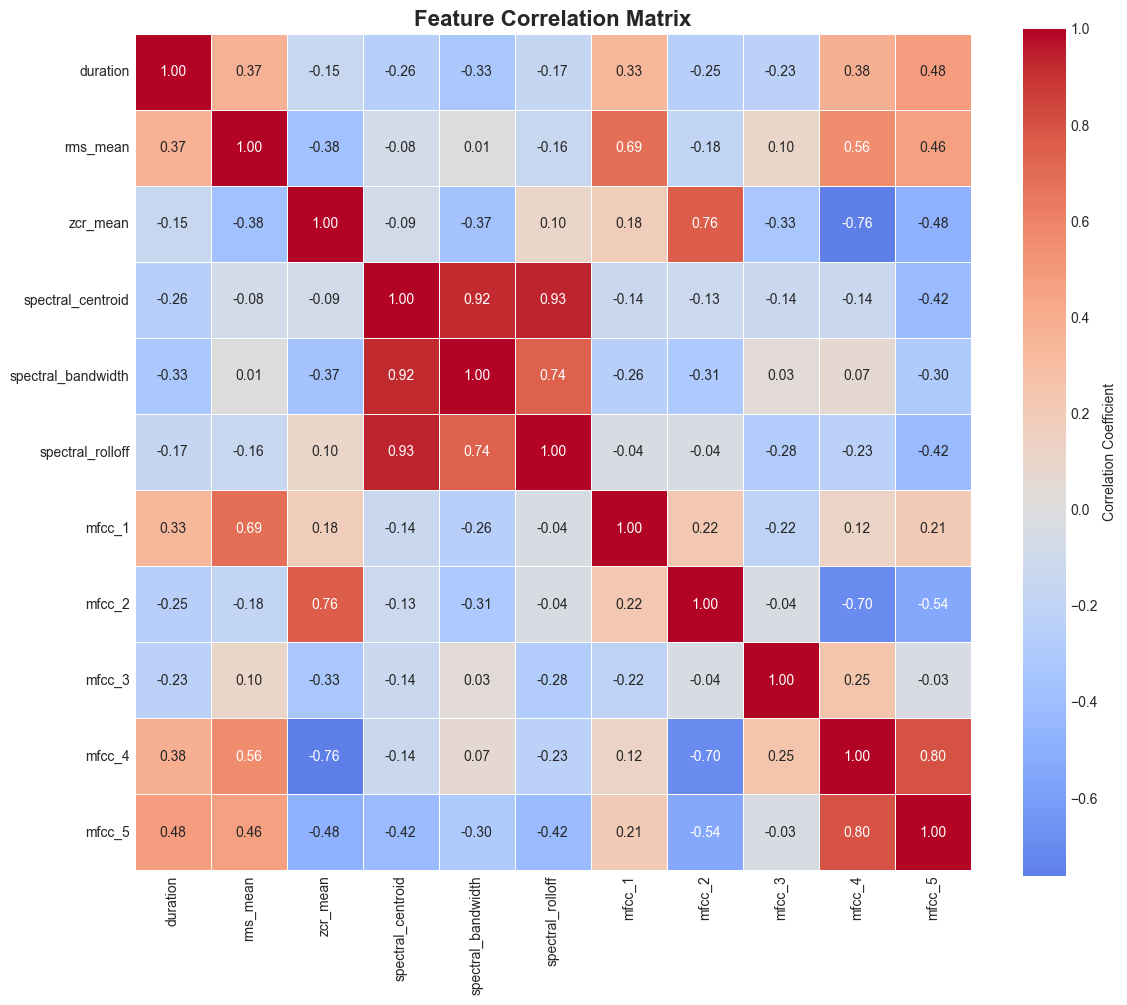

In [46]:
print("\n" + "="*60)
print("Visualization 11: Feature Correlation Matrix")
print("="*60)

# Select numerical features for correlation
feature_cols = ['duration', 'rms_mean', 'zcr_mean', 'spectral_centroid', 
                'spectral_bandwidth', 'spectral_rolloff'] + mfcc_cols[:5]
corr_matrix = df_audio[feature_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(figures_dir / 'icbhi11_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualization 12: Duration vs RMS Energy Scatter


Visualization 12: Duration vs RMS Energy


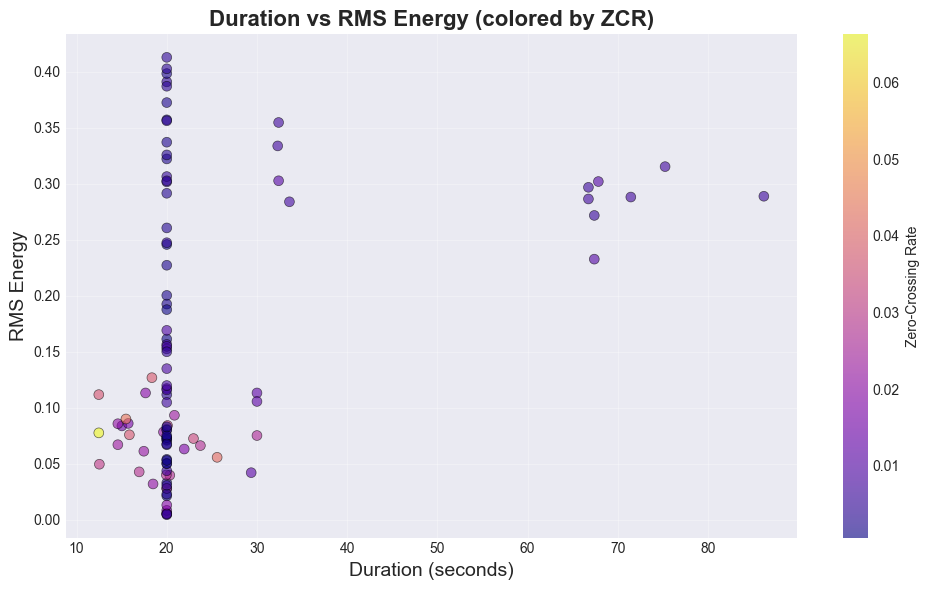

In [47]:
print("\n" + "="*60)
print("Visualization 12: Duration vs RMS Energy")
print("="*60)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_audio['duration'], df_audio['rms_mean'], 
                      c=df_audio['zcr_mean'], cmap='plasma', 
                      alpha=0.6, s=50, edgecolor='black', linewidth=0.5)
plt.colorbar(scatter, label='Zero-Crossing Rate')
plt.title('Duration vs RMS Energy (colored by ZCR)', fontsize=16, fontweight='bold')
plt.xlabel('Duration (seconds)', fontsize=14)
plt.ylabel('RMS Energy', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / 'icbhi12_duration_vs_rms.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Parse Annotation Files

In [48]:
def parse_annotation(file_path):
    """Parse ICBHI annotation file to extract event information"""
    events = []
    try:
        with open(file_path, 'r') as f:
            for line in f:
                parts = line.strip().split('\t')
                if len(parts) >= 4:
                    start = float(parts[0])
                    end = float(parts[1])
                    crackles = int(parts[2])
                    wheezes = int(parts[3])
                    
                    # Determine event type
                    if crackles and wheezes:
                        event_type = 'Both'
                    elif crackles:
                        event_type = 'Crackles'
                    elif wheezes:
                        event_type = 'Wheezes'
                    else:
                        event_type = 'Normal'
                    
                    events.append({
                        'file': file_path.name,
                        'start': start,
                        'end': end,
                        'duration': end - start,
                        'crackles': crackles,
                        'wheezes': wheezes,
                        'event_type': event_type
                    })
    except Exception as e:
        print(f"Error parsing {file_path}: {e}")
    return events

# Parse a sample of annotation files
print("\n" + "="*60)
print("📝 Parsing Annotation Files")
print("="*60)

all_events = []
for anno_file in annotation_files[:50]:  # Parse first 50 annotation files
    events = parse_annotation(anno_file)
    all_events.extend(events)

df_events = pd.DataFrame(all_events)
print(f"Parsed {len(df_events)} events from {len(annotation_files[:50])} annotation files")


📝 Parsing Annotation Files
Parsed 445 events from 50 annotation files


## 10. Visualizations_3

### Visualization 13: Event Type Distribution


Visualization 13: Respiratory Event Type Distribution
event_type
Normal      218
Crackles    157
Wheezes      35
Both         35
Name: count, dtype: int64


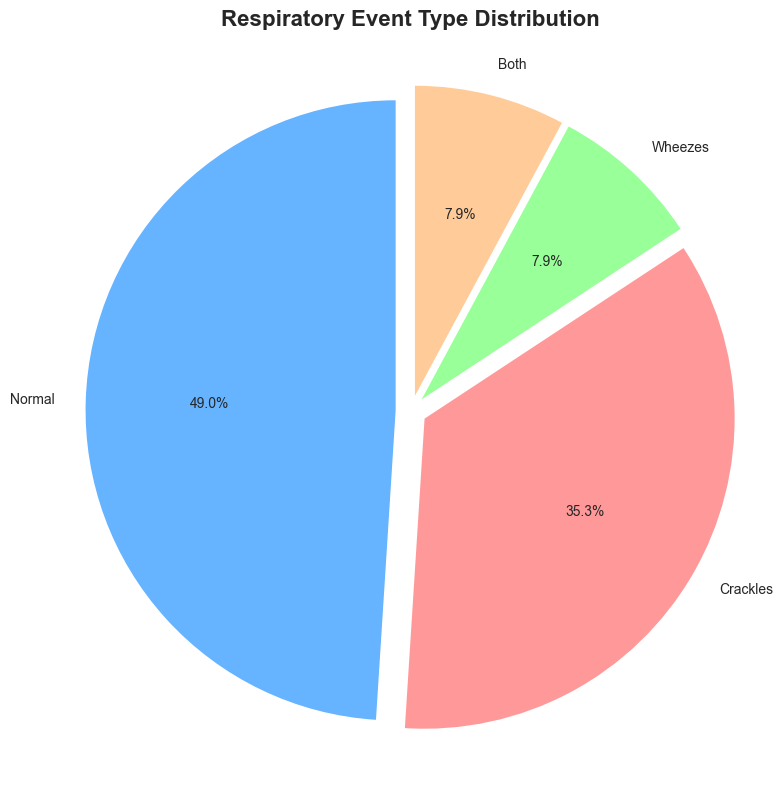

In [49]:
if len(df_events) > 0:
    print("\n" + "="*60)
    print("Visualization 13: Respiratory Event Type Distribution")
    print("="*60)
    
    event_counts = df_events['event_type'].value_counts()
    print(event_counts)
    
    plt.figure(figsize=(8, 8))
    colors = ['#66b3ff', '#ff9999', '#99ff99', '#ffcc99']
    plt.pie(event_counts.values, labels=event_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=[0.05]*len(event_counts))
    plt.title('Respiratory Event Type Distribution', fontsize=16, fontweight='bold')
    plt.axis('equal')
    plt.tight_layout()
    plt.savefig(figures_dir / 'icbhi13_event_types.png', dpi=150, bbox_inches='tight')
    plt.show()

### Visualization 14: Event Duration Distribution by Type


Visualization 14: Event Duration by Type


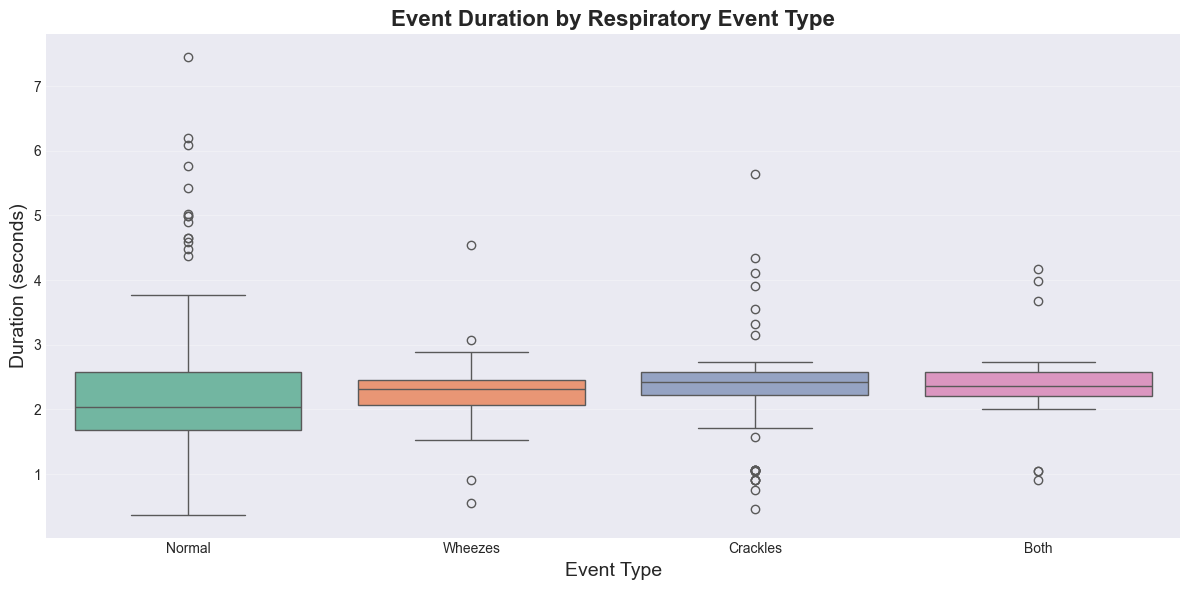


Event duration statistics (seconds):
  Normal: mean=2.25s, median=2.04s
  Wheezes: mean=2.27s, median=2.31s
  Crackles: mean=2.35s, median=2.42s
  Both: mean=2.40s, median=2.37s


In [50]:
if len(df_events) > 0:
    print("\n" + "="*60)
    print("Visualization 14: Event Duration by Type")
    print("="*60)
    
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='event_type', y='duration', data=df_events, palette='Set2')
    plt.title('Event Duration by Respiratory Event Type', fontsize=16, fontweight='bold')
    plt.xlabel('Event Type', fontsize=14)
    plt.ylabel('Duration (seconds)', fontsize=14)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(figures_dir / 'icbhi14_event_durations.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print statistics
    print("\nEvent duration statistics (seconds):")
    for event_type in df_events['event_type'].unique():
        subset = df_events[df_events['event_type'] == event_type]['duration']
        print(f"  {event_type}: mean={subset.mean():.2f}s, median={subset.median():.2f}s")

 ## 11. Key Findings Summary

In [51]:
print("\n" + "="*60)
print("ICBHI 2017 DATASET - SUMMARY")
print("="*60)

summary = pd.DataFrame({
    'Metric': [
        'Total Audio Files',
        'Total Annotation Files',
        'Paired Files',
        'Unique Patients',
        'Chest Locations',
        'Recording Modes',
        'Equipment Types',
        'Average Duration',
        'Total Events (sample)'
    ],
    'Value': [
        len(audio_files),
        len(annotation_files),
        f"{len(common_names)} ({len(common_names)/len(audio_files)*100:.1f}%)",
        df_files['patient_id'].nunique(),
        df_files['chest_location'].nunique(),
        df_files['recording_mode'].nunique(),
        df_files['equipment'].nunique(),
        f"{df_audio['duration'].mean():.2f} s",
        len(df_events) if len(df_events) > 0 else 'N/A'
    ]
})

print("\n", summary.to_string(index=False))

# Save summary
summary.to_csv(ICBHI_PATH / "icbhi_eda_summary.csv", index=False)
df_files.to_csv(ICBHI_PATH / "icbhi_file_list.csv", index=False)
if len(df_events) > 0:
    df_events.to_csv(ICBHI_PATH / "icbhi_events_sample.csv", index=False)

print(f"\n All visualizations saved to: {figures_dir}")
print(f"Summaries saved to: {ICBHI_PATH}/icbhi_eda_summary.csv")


ICBHI 2017 DATASET - SUMMARY

                 Metric        Value
     Total Audio Files          920
Total Annotation Files          922
          Paired Files 920 (100.0%)
       Unique Patients          126
       Chest Locations            7
       Recording Modes            2
       Equipment Types            4
      Average Duration      24.52 s
 Total Events (sample)          445

 All visualizations saved to: ..\reports\figures\icbhi
Summaries saved to: ..\sound_data\icbhi/icbhi_eda_summary.csv
